In [1]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
from env import (MultiLeafThreadEnv, ThreadingConfig)
from viz import  draw_tree_edge_index, draw_local_tree_sequence
from utils import build_backbone_segments_from_reference, get_max_actions, MultiLeafState
from models import Policy

In [2]:
## Example 

REFERENCE_FULL_TREES = [
    {
        "sites": (0, 4),
        # "tree": ("n", 2.0, ("n", 1.0, ("n", 1.0, 0, 1), 2), 3),
        "tree": ("n", 2.0, ("n", 0.25, 0, 1), ("n", 0.25, 2, 3)),
        "nwk": "((A:0.25,B:0.25):1.75,(C:0.25,D:0.25):1.75):1.0;",
    },
    {
        "sites": (4, 8),
        "tree": ("n", 2.0, ("n", 0.25, 0, 2), ("n", 0.25, 1, 3)),
        "nwk":"((A:0.25,C:0.25):1.75,(B:0.25,D:0.25):1.75):1.0;",
    },
]

## TODO: now nwk tree is being given to the model externally. Streamline and make it part of the
## environment later. 
## Bug
site_nwk = [REFERENCE_FULL_TREES[0]["nwk"] if i < 4 else REFERENCE_FULL_TREES[1]["nwk"] for i in range(9)]
GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0], #A
        [0, 0, 0, 0, 1, 1, 1, 1], #B
        [1, 1, 1, 1, 0, 0, 0, 0], #C
        [1, 1, 1, 1, 1, 1, 1, 1], #D
    ],
    dtype=torch.long,
)

LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)

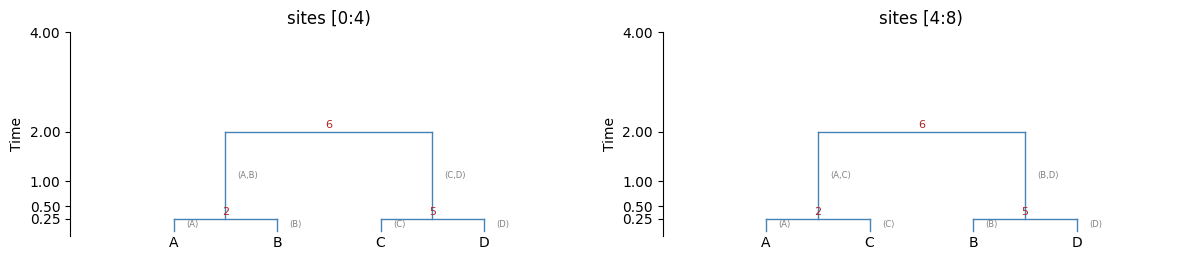

In [3]:
## View this tree. 
full_tree_backbone = build_backbone_segments_from_reference(REFERENCE_FULL_TREES, focal_leaf=-1)
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)

In [4]:
env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
env = MultiLeafThreadEnv(env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)

In [5]:
st = env.reset() ## Resetting the state. Meaning one sequence is removed from here. 

In [6]:
env_cfg

ThreadingConfig(geno=tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]]), time_grid=(0.25, 0.5, 1.0, 2.0, 4.0), mutation_rate=0.4, recomb_rate=0.35, reward_temperature=0.15, sequence_length=8)

In [7]:
env._inner_env._site_tree_for_encoding(st.inner_state)


SiteBackboneTree(site=0, edge_index=tensor([[3, 3, 4, 4],
        [1, 2, 0, 3]]), num_nodes=5, root=4, node_times=tensor([0.0000, 0.0000, 0.0000, 0.2500, 2.0000]), branch_children=(0, 1, 2, 3), branch_signatures=((1,), (2,), (3,), (2, 3)), parent_of_child=(4, 3, 3, 4, -1), node_sample_ids=(1, 2, 3, -1, -1), descendant_signatures=((1,), (2,), (3,), (2, 3), (1, 2, 3)))

In [8]:
## encoding is done here. We need to make changes here. 
## Here, there's need to properly initialize the node features and valid action masks. 
## No need for genotype-window at the encoding step. It'll be used during the reward for reparamaterization. 
# encoded_state = env.encode(st)

In [9]:
policy_model = Policy(LEAF_NAMES, device='cpu')

In [10]:
site_tree = env._inner_env._site_tree_for_encoding(st.inner_state)
action_choices = env._inner_env.site_choices[st.inner_state.site_index]
action_logits, action_probs, edge_features, node_embeddings, leaf_feature = policy_model(
    site_tree,
    st.current_focal_leaf,
    action_choices,
    time_grid=env_cfg.time_grid,
)


In [11]:
act = int(np.argmax(action_probs.detach().numpy()))

In [12]:
st, reward, done = env.step(st, act)

In [13]:
st 

MultiLeafState(current_full_trees=({'sites': (0, 4), 'tree': ('n', 2.0, ('n', 0.25, 0, 1), ('n', 0.25, 2, 3))}, {'sites': (4, 8), 'tree': ('n', 2.0, ('n', 0.25, 0, 2), ('n', 0.25, 1, 3))}), leaves_threaded=(), current_focal_leaf=0, inner_state=ThreadPathState(site_index=1, choices=(ThreadChoice(site=0, branch_child=0, branch_signature=(1,), time_idx=3, time_value=2.0, is_root_branch=False),), recomb_count=0))

In [ ]:
fina


=== episode step 0 | leaf A | site 0 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1251 | [leaf A] site 0 -> branch (B) @ t0=0.25 [start]
  row 01 -> env action 01 | p=0.1253 | [leaf A] site 0 -> branch (B) @ t1=0.50 [start]
  row 02 -> env action 02 | p=0.1255 | [leaf A] site 0 -> branch (B) @ t2=1.00 [start]
  row 03 -> env action 03 | p=0.1260 | [leaf A] site 0 -> branch (B) @ t3=2.00 [start]
  row 04 -> env action 04 | p=0.1232 | [leaf A] site 0 -> branch (C) @ t0=0.25 [start]
  row 05 -> env action 05 | p=0.1249 | [leaf A] site 0 -> branch (C,D) @ t1=0.50 [start]
  row 06 -> env action 06 | p=0.1251 | [leaf A] site 0 -> branch (C,D) @ t2=1.00 [start]
  row 07 -> env action 07 | p=0.1250 | [leaf A] site 0 -> branch root @ t4=4.00 [start]
Selected: row 5 -> env action 5 | [leaf A] site 0 -> branch (C,D) @ t1=0.50 [start]
Local log reward: -32.5865 | positive reward factor: 7.0449e-15
Local tree sequence after selected action:


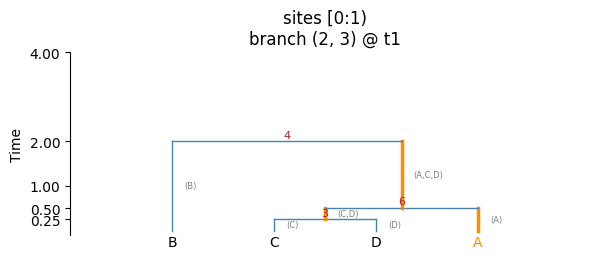


=== episode step 1 | leaf A | site 1 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1251 | [leaf A] site 1 -> branch (B) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1253 | [leaf A] site 1 -> branch (B) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1255 | [leaf A] site 1 -> branch (B) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1260 | [leaf A] site 1 -> branch (B) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1232 | [leaf A] site 1 -> branch (C) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1249 | [leaf A] site 1 -> branch (C,D) @ t1=0.50 [stay]
  row 06 -> env action 06 | p=0.1251 | [leaf A] site 1 -> branch (C,D) @ t2=1.00 [stay]
  row 07 -> env action 07 | p=0.1250 | [leaf A] site 1 -> branch root @ t4=4.00 [recomb]
Selected: row 0 -> env action 0 | [leaf A] site 1 -> branch (B) @ t0=0.25 [recomb]
Local log reward: -30.7674 | positive reward factor: 4.3441e-14
Local tree sequence after selected action:


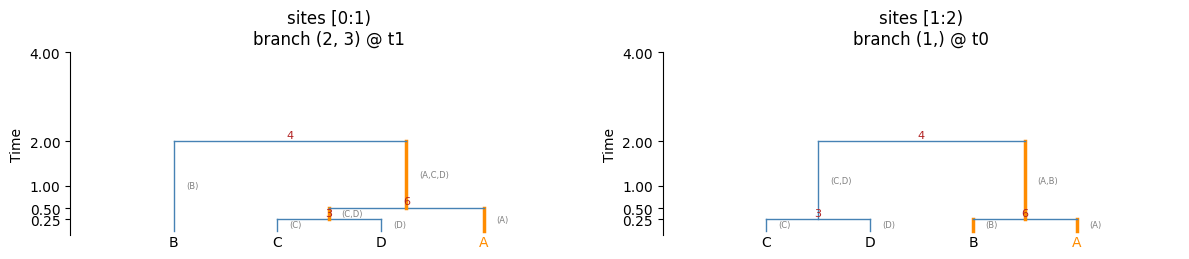


=== episode step 2 | leaf A | site 2 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1251 | [leaf A] site 2 -> branch (B) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.1253 | [leaf A] site 2 -> branch (B) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.1255 | [leaf A] site 2 -> branch (B) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.1260 | [leaf A] site 2 -> branch (B) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.1232 | [leaf A] site 2 -> branch (C) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1249 | [leaf A] site 2 -> branch (C,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1251 | [leaf A] site 2 -> branch (C,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1250 | [leaf A] site 2 -> branch root @ t4=4.00 [recomb]
Selected: row 4 -> env action 4 | [leaf A] site 2 -> branch (C) @ t0=0.25 [recomb]
Local log reward: -44.8811 | positive reward factor: 3.2239e-20
Local tree sequence after selected action:


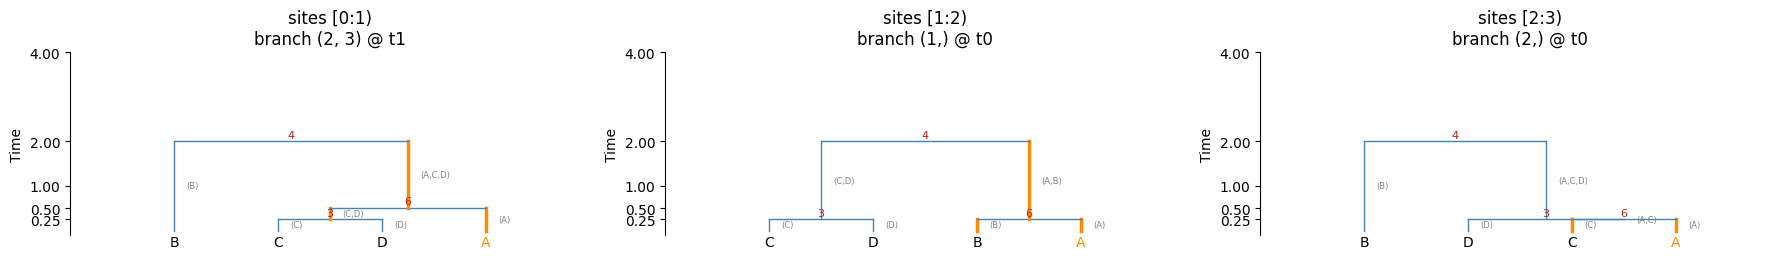


=== episode step 3 | leaf A | site 3 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1251 | [leaf A] site 3 -> branch (B) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1253 | [leaf A] site 3 -> branch (B) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1255 | [leaf A] site 3 -> branch (B) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1260 | [leaf A] site 3 -> branch (B) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1232 | [leaf A] site 3 -> branch (C) @ t0=0.25 [stay]
  row 05 -> env action 05 | p=0.1249 | [leaf A] site 3 -> branch (C,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1251 | [leaf A] site 3 -> branch (C,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1250 | [leaf A] site 3 -> branch root @ t4=4.00 [recomb]
Selected: row 1 -> env action 1 | [leaf A] site 3 -> branch (B) @ t1=0.50 [recomb]
Local log reward: -33.4435 | positive reward factor: 2.9899e-15
Local tree sequence after selected action:


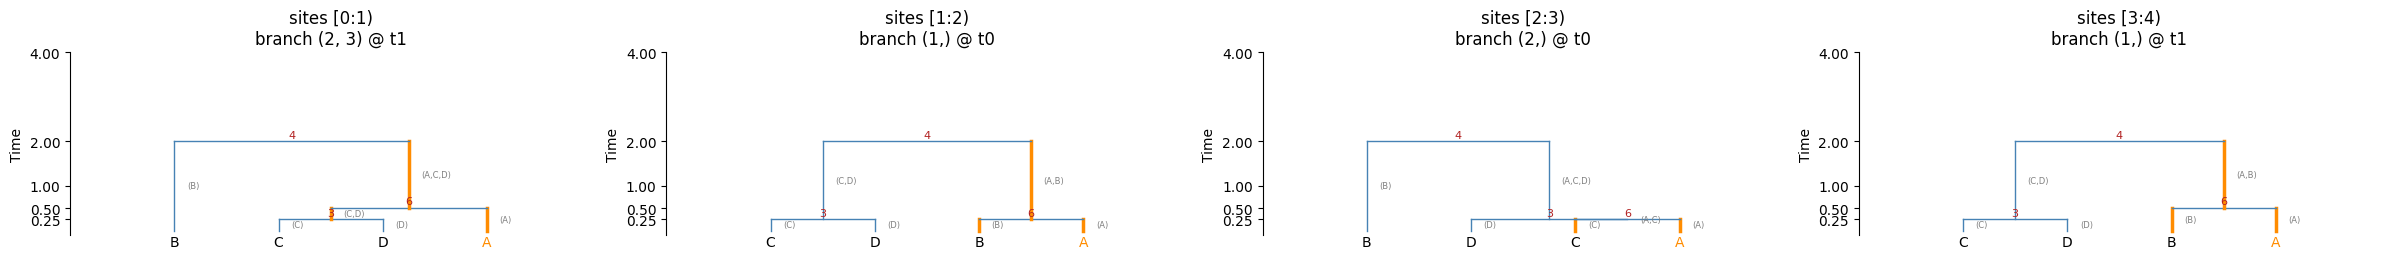


=== episode step 4 | leaf A | site 4 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1242 | [leaf A] site 4 -> branch (C) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1243 | [leaf A] site 4 -> branch (C) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1245 | [leaf A] site 4 -> branch (C) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1250 | [leaf A] site 4 -> branch (C) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1255 | [leaf A] site 4 -> branch (B) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1247 | [leaf A] site 4 -> branch (B,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1249 | [leaf A] site 4 -> branch (B,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1268 | [leaf A] site 4 -> branch root @ t4=4.00 [recomb]
Selected: row 0 -> env action 0 | [leaf A] site 4 -> branch (C) @ t0=0.25 [recomb]
Local log reward: -30.7674 | positive reward factor: 4.3441e-14
Local tree sequence after selected action:


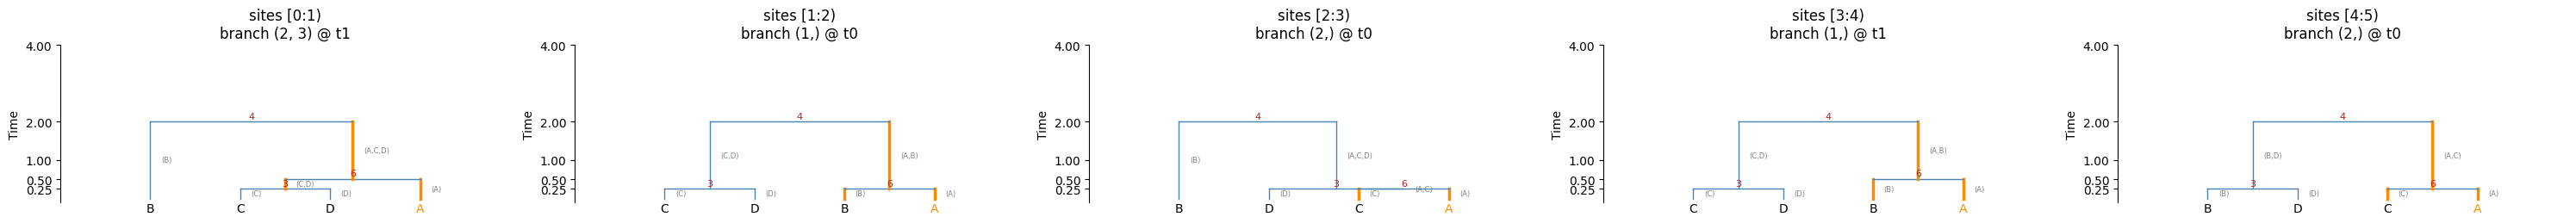


=== episode step 5 | leaf A | site 5 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1242 | [leaf A] site 5 -> branch (C) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.1243 | [leaf A] site 5 -> branch (C) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.1245 | [leaf A] site 5 -> branch (C) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.1250 | [leaf A] site 5 -> branch (C) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.1255 | [leaf A] site 5 -> branch (B) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1247 | [leaf A] site 5 -> branch (B,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1249 | [leaf A] site 5 -> branch (B,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1268 | [leaf A] site 5 -> branch root @ t4=4.00 [recomb]
Selected: row 1 -> env action 1 | [leaf A] site 5 -> branch (C) @ t1=0.50 [stay]
Local log reward: -33.4435 | positive reward factor: 2.9899e-15
Local tree sequence after selected action:


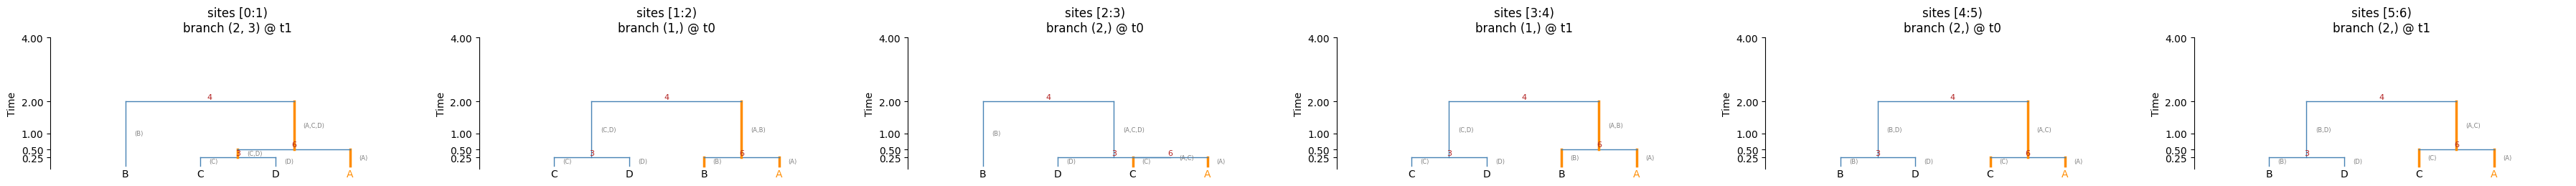


=== episode step 6 | leaf A | site 6 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1242 | [leaf A] site 6 -> branch (C) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.1243 | [leaf A] site 6 -> branch (C) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.1245 | [leaf A] site 6 -> branch (C) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.1250 | [leaf A] site 6 -> branch (C) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.1255 | [leaf A] site 6 -> branch (B) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1247 | [leaf A] site 6 -> branch (B,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1249 | [leaf A] site 6 -> branch (B,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1268 | [leaf A] site 6 -> branch root @ t4=4.00 [recomb]
Selected: row 4 -> env action 4 | [leaf A] site 6 -> branch (B) @ t0=0.25 [recomb]
Local log reward: -44.8811 | positive reward factor: 3.2239e-20
Local tree sequence after selected action:


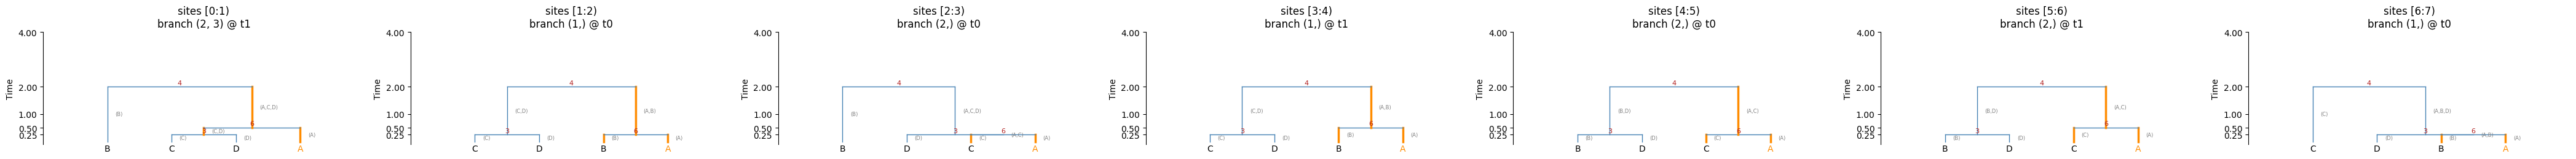


=== episode step 7 | leaf A | site 7 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1242 | [leaf A] site 7 -> branch (C) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1243 | [leaf A] site 7 -> branch (C) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1245 | [leaf A] site 7 -> branch (C) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1250 | [leaf A] site 7 -> branch (C) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1255 | [leaf A] site 7 -> branch (B) @ t0=0.25 [stay]
  row 05 -> env action 05 | p=0.1247 | [leaf A] site 7 -> branch (B,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1249 | [leaf A] site 7 -> branch (B,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1268 | [leaf A] site 7 -> branch root @ t4=4.00 [recomb]
Selected: row 5 -> env action 5 | [leaf A] site 7 -> branch (B,D) @ t1=0.50 [recomb]
Local log reward: -40.7180 | positive reward factor: 2.0721e-18
Local tree sequence after selected action:


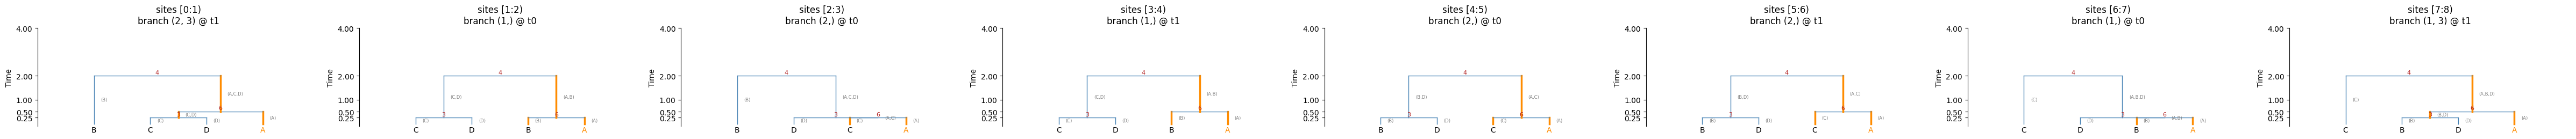


=== episode step 8 | leaf B | site 0 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1667 | [leaf B] site 0 -> branch (C) @ t0=0.25 [start]
  row 01 -> env action 01 | p=0.1661 | [leaf B] site 0 -> branch (C,D) @ t1=0.50 [start]
  row 02 -> env action 02 | p=0.1664 | [leaf B] site 0 -> branch (A) @ t0=0.25 [start]
  row 03 -> env action 03 | p=0.1661 | [leaf B] site 0 -> branch root @ t2=1.00 [start]
  row 04 -> env action 04 | p=0.1668 | [leaf B] site 0 -> branch root @ t3=2.00 [start]
  row 05 -> env action 05 | p=0.1680 | [leaf B] site 0 -> branch root @ t4=4.00 [start]
Selected: row 3 -> env action 3 | [leaf B] site 0 -> branch root @ t2=1.00 [start]
Local log reward: -31.7831 | positive reward factor: 1.5732e-14
Local tree sequence after selected action:


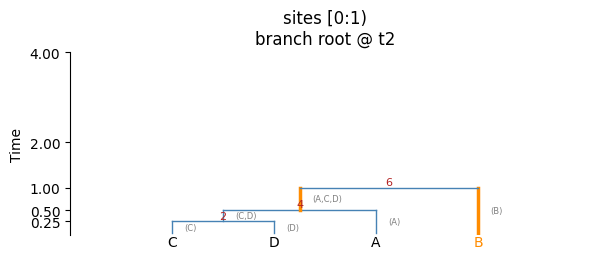


=== episode step 9 | leaf B | site 1 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1249 | [leaf B] site 1 -> branch (C) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1245 | [leaf B] site 1 -> branch (C,D) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1247 | [leaf B] site 1 -> branch (C,D) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1252 | [leaf B] site 1 -> branch (C,D) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1247 | [leaf B] site 1 -> branch (A) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1248 | [leaf B] site 1 -> branch (A) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1251 | [leaf B] site 1 -> branch (A) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1260 | [leaf B] site 1 -> branch root @ t4=4.00 [stay]
Selected: row 7 -> env action 7 | [leaf B] site 1 -> branch root @ t4=4.00 [stay]
Local log reward: -54.5009 | positive reward factor: 2.1407e-24
Local tree sequence after selected action:


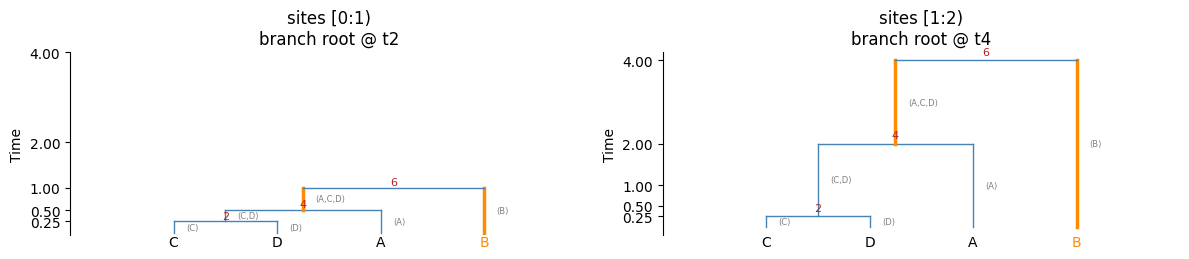


=== episode step 10 | leaf B | site 2 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1659 | [leaf B] site 2 -> branch (D) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1653 | [leaf B] site 2 -> branch (C) @ t0=0.25 [recomb]
  row 02 -> env action 02 | p=0.1663 | [leaf B] site 2 -> branch root @ t1=0.50 [stay]
  row 03 -> env action 03 | p=0.1666 | [leaf B] site 2 -> branch root @ t2=1.00 [stay]
  row 04 -> env action 04 | p=0.1673 | [leaf B] site 2 -> branch root @ t3=2.00 [stay]
  row 05 -> env action 05 | p=0.1686 | [leaf B] site 2 -> branch root @ t4=4.00 [stay]
Selected: row 0 -> env action 0 | [leaf B] site 2 -> branch (D) @ t0=0.25 [recomb]
Local log reward: -52.0012 | positive reward factor: 2.6071e-23
Local tree sequence after selected action:


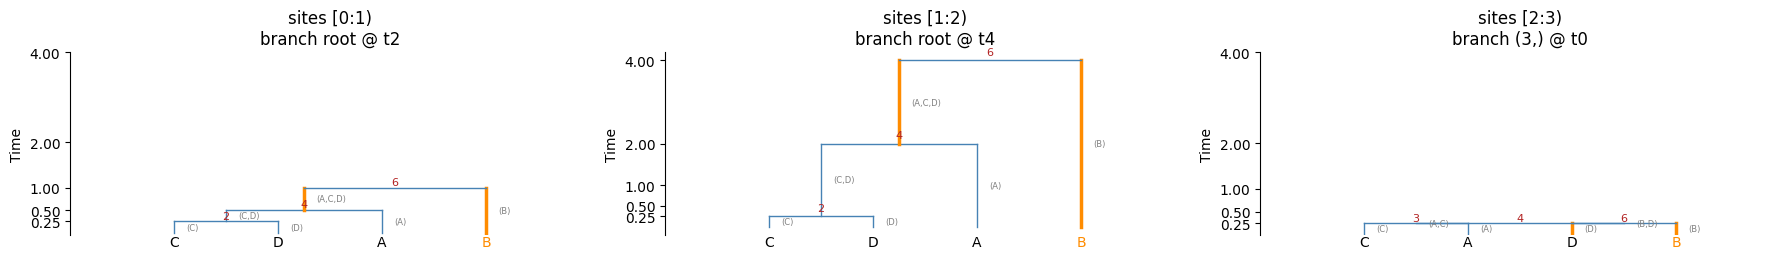


=== episode step 11 | leaf B | site 3 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1249 | [leaf B] site 3 -> branch (C) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1245 | [leaf B] site 3 -> branch (C,D) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1247 | [leaf B] site 3 -> branch (C,D) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1252 | [leaf B] site 3 -> branch (C,D) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1247 | [leaf B] site 3 -> branch (A) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1248 | [leaf B] site 3 -> branch (A) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1251 | [leaf B] site 3 -> branch (A) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1260 | [leaf B] site 3 -> branch root @ t4=4.00 [recomb]
Selected: row 6 -> env action 6 | [leaf B] site 3 -> branch (A) @ t2=1.00 [recomb]
Local log reward: -38.1247 | positive reward factor: 2.7711e-17
Local tree sequence after selected action:


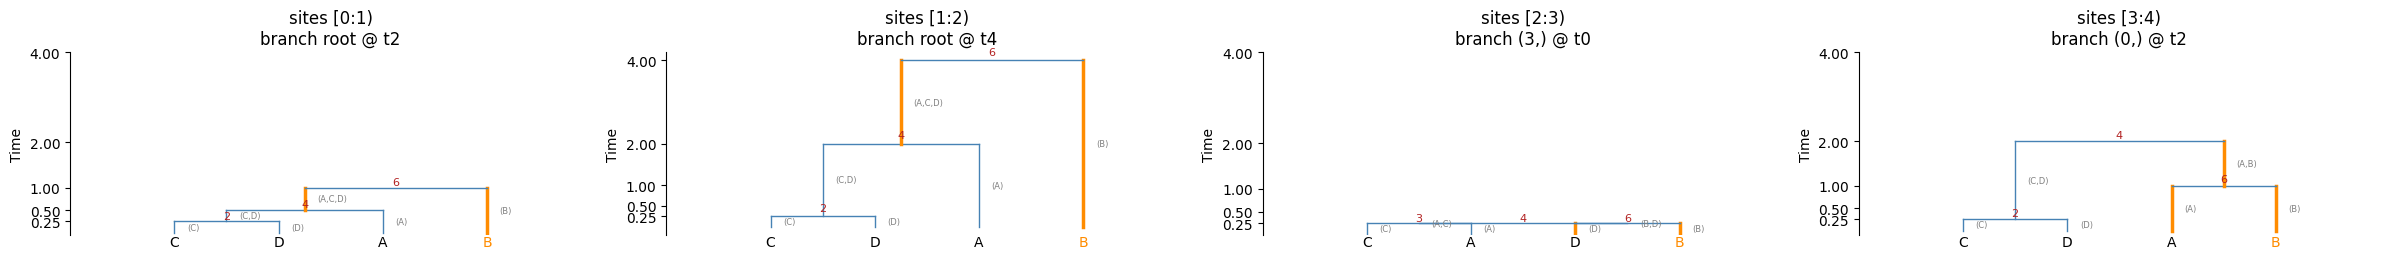


=== episode step 12 | leaf B | site 4 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1245 | [leaf B] site 4 -> branch (D) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1246 | [leaf B] site 4 -> branch (D) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1248 | [leaf B] site 4 -> branch (D) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1253 | [leaf B] site 4 -> branch (D) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1240 | [leaf B] site 4 -> branch (C) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1251 | [leaf B] site 4 -> branch (A,C) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1253 | [leaf B] site 4 -> branch (A,C) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1265 | [leaf B] site 4 -> branch root @ t4=4.00 [recomb]
Selected: row 2 -> env action 2 | [leaf B] site 4 -> branch (D) @ t2=1.00 [recomb]
Local log reward: -38.1247 | positive reward factor: 2.7711e-17
Local tree sequence after selected action:


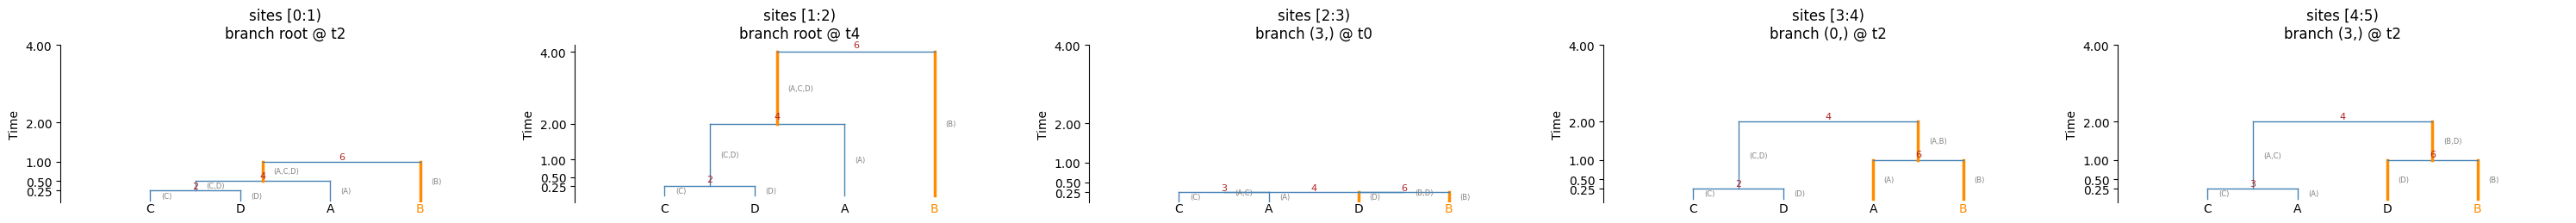


=== episode step 13 | leaf B | site 5 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1107 | [leaf B] site 5 -> branch (D) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.1108 | [leaf B] site 5 -> branch (D) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.1110 | [leaf B] site 5 -> branch (D) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.1114 | [leaf B] site 5 -> branch (D) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.1103 | [leaf B] site 5 -> branch (C) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1104 | [leaf B] site 5 -> branch (C) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1117 | [leaf B] site 5 -> branch (A) @ t0=0.25 [recomb]
  row 07 -> env action 07 | p=0.1114 | [leaf B] site 5 -> branch (A,C) @ t2=1.00 [recomb]
  row 08 -> env action 08 | p=0.1124 | [leaf B] site 5 -> branch root @ t4=4.00 [recomb]
Selected: row 8 -> env action 8 | [leaf B] site 5 -> branch root @ t4=4.00 [recomb]
Local log reward: -55.5016 | positive reward factor: 7.8701e-25


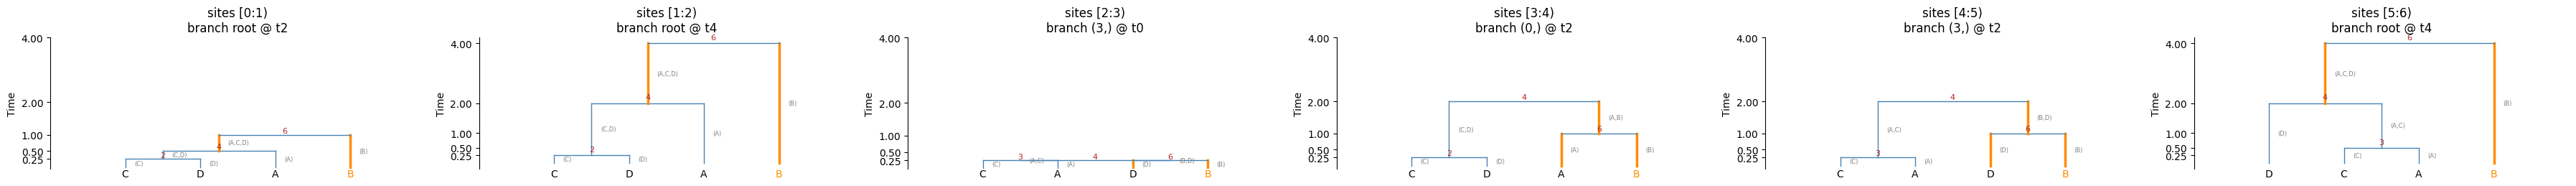


=== episode step 14 | leaf B | site 6 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1243 | [leaf B] site 6 -> branch (C) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1244 | [leaf B] site 6 -> branch (C) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1247 | [leaf B] site 6 -> branch (C) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1251 | [leaf B] site 6 -> branch (C) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1248 | [leaf B] site 6 -> branch (D) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1248 | [leaf B] site 6 -> branch (A,D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1250 | [leaf B] site 6 -> branch (A,D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1268 | [leaf B] site 6 -> branch root @ t4=4.00 [stay]
Selected: row 7 -> env action 7 | [leaf B] site 6 -> branch root @ t4=4.00 [stay]
Local log reward: -28.1991 | positive reward factor: 5.6660e-13
Local tree sequence after selected action:


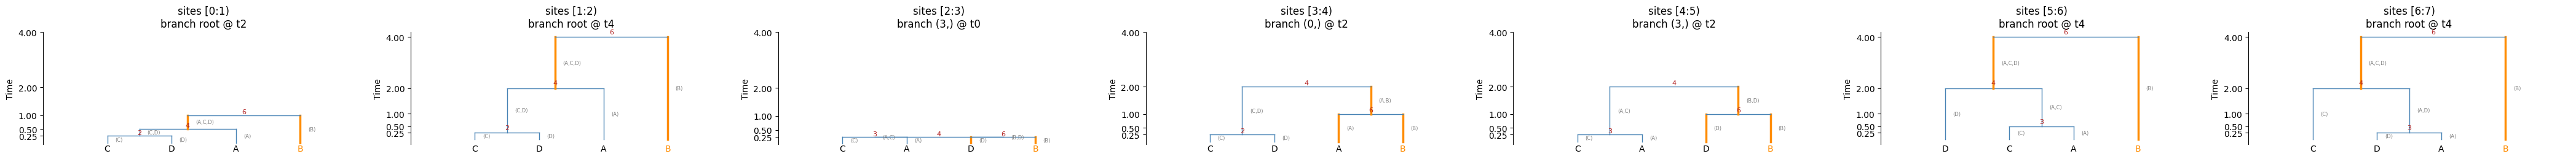


=== episode step 15 | leaf B | site 7 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1105 | [leaf B] site 7 -> branch (C) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1106 | [leaf B] site 7 -> branch (C) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1108 | [leaf B] site 7 -> branch (C) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1112 | [leaf B] site 7 -> branch (C) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1109 | [leaf B] site 7 -> branch (D) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1110 | [leaf B] site 7 -> branch (D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1110 | [leaf B] site 7 -> branch (A) @ t0=0.25 [recomb]
  row 07 -> env action 07 | p=0.1111 | [leaf B] site 7 -> branch (A,D) @ t2=1.00 [recomb]
  row 08 -> env action 08 | p=0.1127 | [leaf B] site 7 -> branch root @ t4=4.00 [stay]
Selected: row 7 -> env action 7 | [leaf B] site 7 -> branch (A,D) @ t2=1.00 [recomb]
Local log reward: -46.4610 | positive reward factor: 6.64

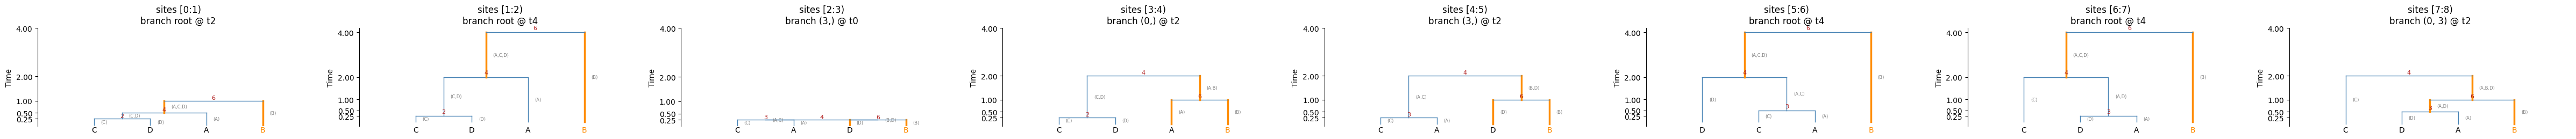


=== episode step 16 | leaf C | site 0 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1239 | [leaf C] site 0 -> branch (D) @ t0=0.25 [start]
  row 01 -> env action 01 | p=0.1241 | [leaf C] site 0 -> branch (D) @ t1=0.50 [start]
  row 02 -> env action 02 | p=0.1256 | [leaf C] site 0 -> branch (A) @ t0=0.25 [start]
  row 03 -> env action 03 | p=0.1260 | [leaf C] site 0 -> branch (A,D) @ t2=1.00 [start]
  row 04 -> env action 04 | p=0.1248 | [leaf C] site 0 -> branch (B) @ t0=0.25 [start]
  row 05 -> env action 05 | p=0.1249 | [leaf C] site 0 -> branch (B) @ t1=0.50 [start]
  row 06 -> env action 06 | p=0.1248 | [leaf C] site 0 -> branch root @ t3=2.00 [start]
  row 07 -> env action 07 | p=0.1258 | [leaf C] site 0 -> branch root @ t4=4.00 [start]
Selected: row 0 -> env action 0 | [leaf C] site 0 -> branch (D) @ t0=0.25 [start]
Local log reward: -34.1072 | positive reward factor: 1.5397e-15
Local tree sequence after selected action:


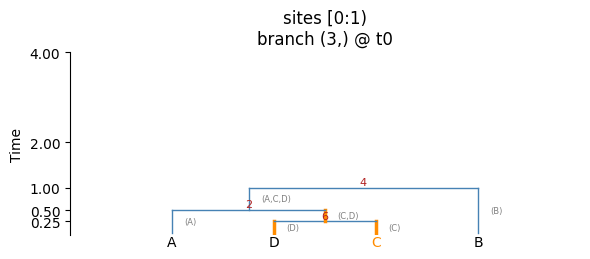


=== episode step 17 | leaf C | site 1 ===
Action probabilities:
  row 00 -> env action 00 | p=0.0825 | [leaf C] site 1 -> branch (D) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.0826 | [leaf C] site 1 -> branch (D) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.0827 | [leaf C] site 1 -> branch (D) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.0831 | [leaf C] site 1 -> branch (D) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.0836 | [leaf C] site 1 -> branch (A) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.0837 | [leaf C] site 1 -> branch (A) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.0838 | [leaf C] site 1 -> branch (A) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.0849 | [leaf C] site 1 -> branch (A,D) @ t4=4.00 [recomb]
  row 08 -> env action 08 | p=0.0831 | [leaf C] site 1 -> branch (B) @ t0=0.25 [recomb]
  row 09 -> env action 09 | p=0.0832 | [leaf C] site 1 -> branch (B) @ t1=0.50 [recomb]
  row 10 -> env action 10 | p=0.0833 | [leaf C] site 1 -> bra

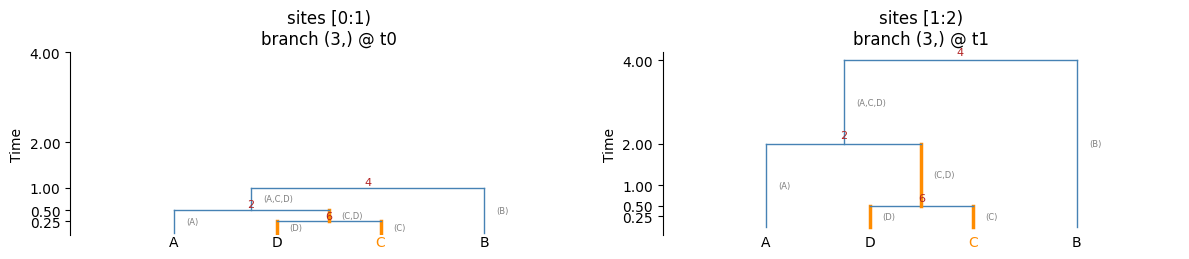


=== episode step 18 | leaf C | site 2 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1675 | [leaf C] site 2 -> branch (A) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1650 | [leaf C] site 2 -> branch (D) @ t0=0.25 [recomb]
  row 02 -> env action 02 | p=0.1660 | [leaf C] site 2 -> branch root @ t1=0.50 [recomb]
  row 03 -> env action 03 | p=0.1663 | [leaf C] site 2 -> branch root @ t2=1.00 [recomb]
  row 04 -> env action 04 | p=0.1670 | [leaf C] site 2 -> branch root @ t3=2.00 [recomb]
  row 05 -> env action 05 | p=0.1683 | [leaf C] site 2 -> branch root @ t4=4.00 [recomb]
Selected: row 2 -> env action 2 | [leaf C] site 2 -> branch root @ t1=0.50 [recomb]
Local log reward: -45.6268 | positive reward factor: 1.5294e-20
Local tree sequence after selected action:


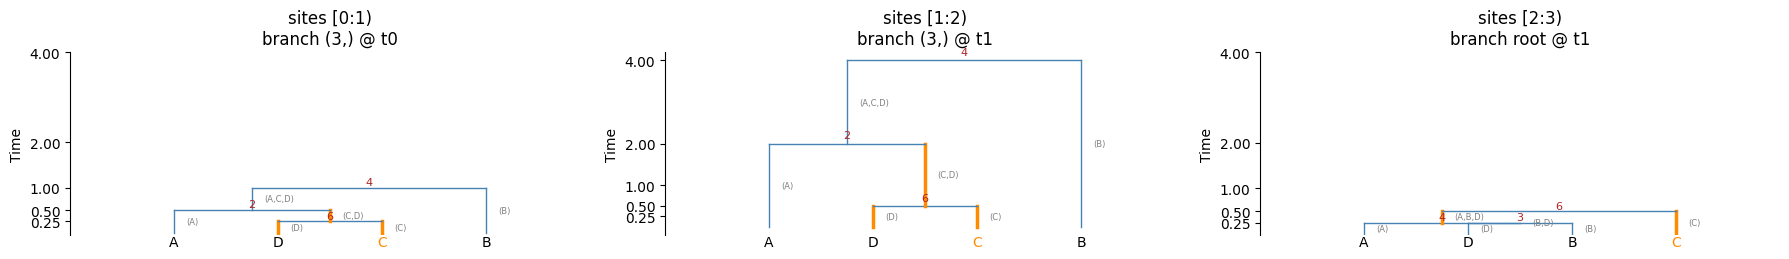


=== episode step 19 | leaf C | site 3 ===
Action probabilities:
  row 00 -> env action 00 | p=0.0993 | [leaf C] site 3 -> branch (D) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.0994 | [leaf C] site 3 -> branch (D) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.0996 | [leaf C] site 3 -> branch (D) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1000 | [leaf C] site 3 -> branch (D) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.0992 | [leaf C] site 3 -> branch (A) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.0993 | [leaf C] site 3 -> branch (A) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.0994 | [leaf C] site 3 -> branch (A) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1014 | [leaf C] site 3 -> branch (B) @ t0=0.25 [recomb]
  row 08 -> env action 08 | p=0.1015 | [leaf C] site 3 -> branch (B) @ t1=0.50 [recomb]
  row 09 -> env action 09 | p=0.1008 | [leaf C] site 3 -> branch root @ t4=4.00 [stay]
Selected: row 3 -> env action 3 | [leaf C] site 3 -> bra

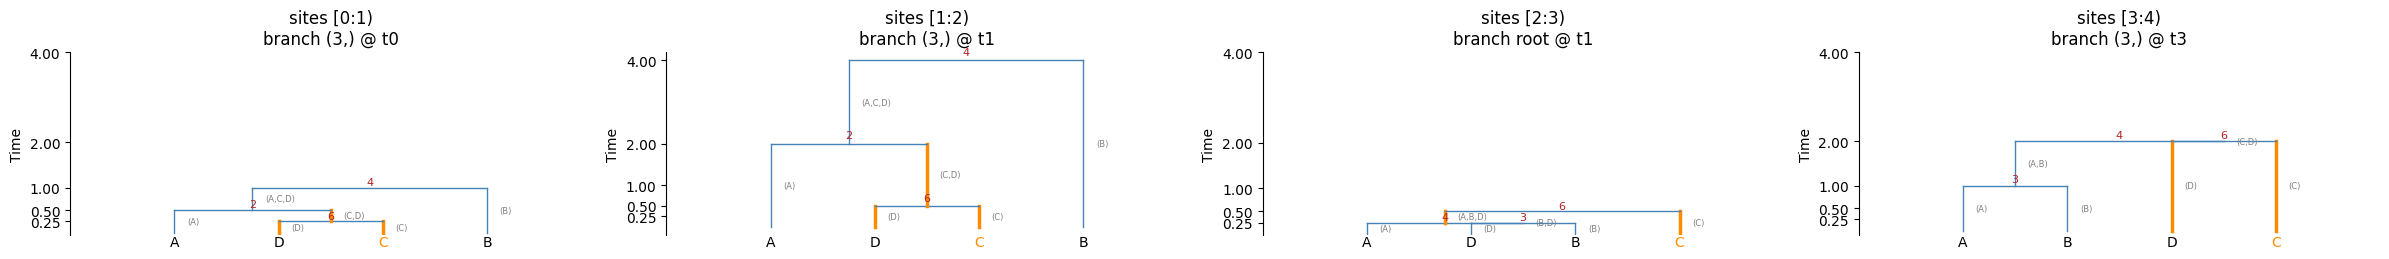


=== episode step 20 | leaf C | site 4 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1002 | [leaf C] site 4 -> branch (A) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1003 | [leaf C] site 4 -> branch (A) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1005 | [leaf C] site 4 -> branch (A) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1009 | [leaf C] site 4 -> branch (A) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.0987 | [leaf C] site 4 -> branch (D) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.0988 | [leaf C] site 4 -> branch (D) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.0990 | [leaf C] site 4 -> branch (D) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.1004 | [leaf C] site 4 -> branch (B) @ t0=0.25 [recomb]
  row 08 -> env action 08 | p=0.1005 | [leaf C] site 4 -> branch (B) @ t1=0.50 [recomb]
  row 09 -> env action 09 | p=0.1007 | [leaf C] site 4 -> branch root @ t4=4.00 [recomb]
Selected: row 6 -> env action 6 | [leaf C] site 4 -> b

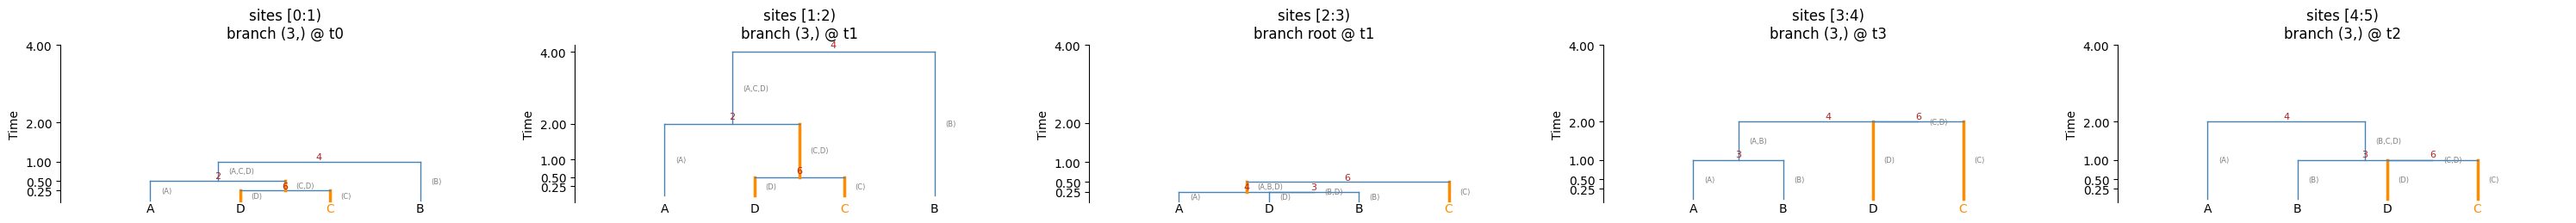


=== episode step 21 | leaf C | site 5 ===
Action probabilities:
  row 00 -> env action 00 | p=0.0825 | [leaf C] site 5 -> branch (D) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.0826 | [leaf C] site 5 -> branch (D) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.0827 | [leaf C] site 5 -> branch (D) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.0831 | [leaf C] site 5 -> branch (D) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.0836 | [leaf C] site 5 -> branch (A) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.0837 | [leaf C] site 5 -> branch (A) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.0838 | [leaf C] site 5 -> branch (A) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.0849 | [leaf C] site 5 -> branch (A,D) @ t4=4.00 [recomb]
  row 08 -> env action 08 | p=0.0831 | [leaf C] site 5 -> branch (B) @ t0=0.25 [recomb]
  row 09 -> env action 09 | p=0.0832 | [leaf C] site 5 -> branch (B) @ t1=0.50 [recomb]
  row 10 -> env action 10 | p=0.0833 | [leaf C] site 

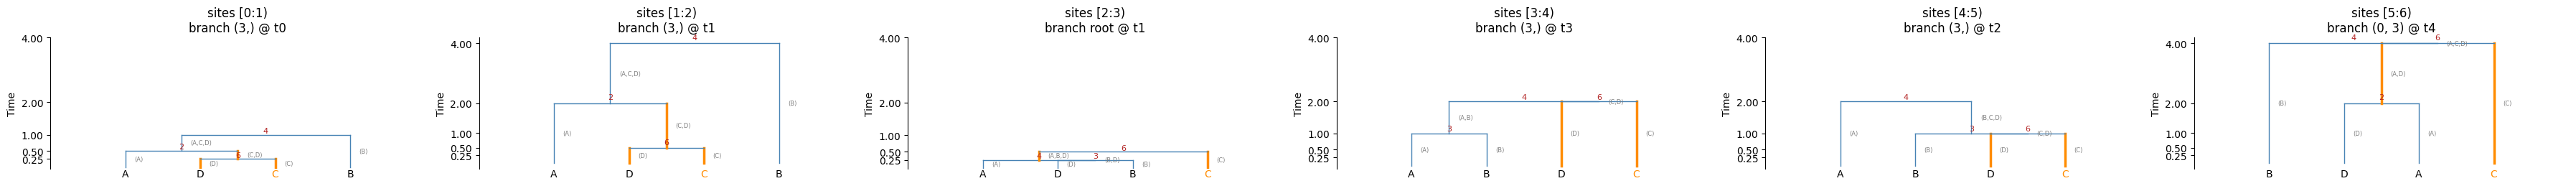


=== episode step 22 | leaf C | site 6 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1096 | [leaf C] site 6 -> branch (D) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1113 | [leaf C] site 6 -> branch (A,D) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.1115 | [leaf C] site 6 -> branch (A,D) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.1119 | [leaf C] site 6 -> branch (A,D) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.1128 | [leaf C] site 6 -> branch (A,D) @ t4=4.00 [stay]
  row 05 -> env action 05 | p=0.1104 | [leaf C] site 6 -> branch (B) @ t0=0.25 [recomb]
  row 06 -> env action 06 | p=0.1105 | [leaf C] site 6 -> branch (B) @ t1=0.50 [recomb]
  row 07 -> env action 07 | p=0.1107 | [leaf C] site 6 -> branch (B) @ t2=1.00 [recomb]
  row 08 -> env action 08 | p=0.1112 | [leaf C] site 6 -> branch (B) @ t3=2.00 [recomb]
Selected: row 0 -> env action 0 | [leaf C] site 6 -> branch (D) @ t0=0.25 [recomb]
Local log reward: -44.6148 | positive reward factor: 4.2078e

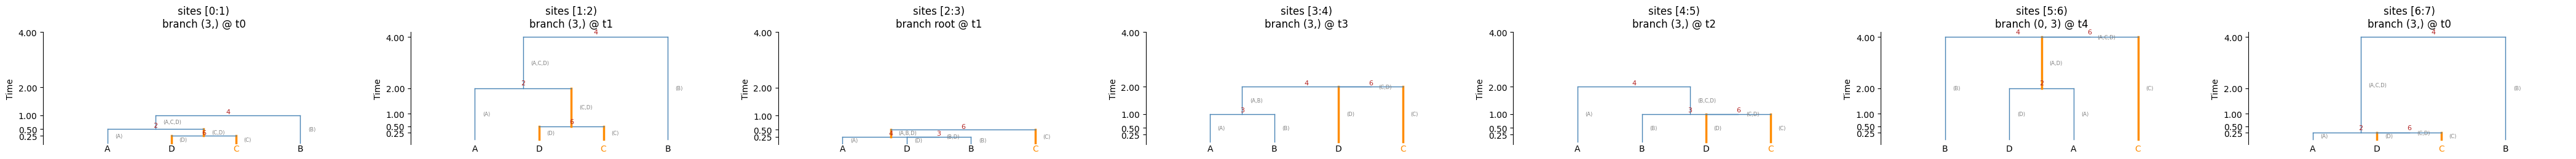


=== episode step 23 | leaf C | site 7 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1239 | [leaf C] site 7 -> branch (D) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.1241 | [leaf C] site 7 -> branch (D) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.1256 | [leaf C] site 7 -> branch (A) @ t0=0.25 [recomb]
  row 03 -> env action 03 | p=0.1260 | [leaf C] site 7 -> branch (A,D) @ t2=1.00 [recomb]
  row 04 -> env action 04 | p=0.1248 | [leaf C] site 7 -> branch (B) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.1249 | [leaf C] site 7 -> branch (B) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.1248 | [leaf C] site 7 -> branch root @ t3=2.00 [recomb]
  row 07 -> env action 07 | p=0.1258 | [leaf C] site 7 -> branch root @ t4=4.00 [recomb]
Selected: row 2 -> env action 2 | [leaf C] site 7 -> branch (A) @ t0=0.25 [recomb]
Local log reward: -42.2387 | positive reward factor: 4.5288e-19
Local tree sequence after selected action:


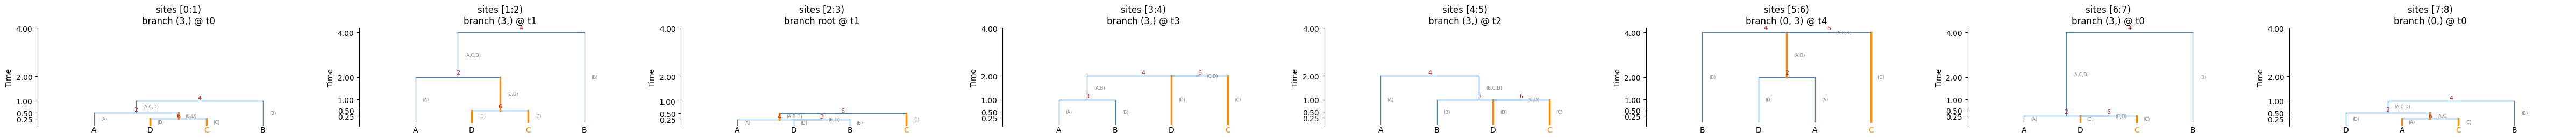


=== episode step 24 | leaf D | site 0 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1244 | [leaf D] site 0 -> branch (A) @ t0=0.25 [start]
  row 01 -> env action 01 | p=0.1245 | [leaf D] site 0 -> branch (A) @ t1=0.50 [start]
  row 02 -> env action 02 | p=0.1256 | [leaf D] site 0 -> branch (C) @ t0=0.25 [start]
  row 03 -> env action 03 | p=0.1247 | [leaf D] site 0 -> branch (A,C) @ t2=1.00 [start]
  row 04 -> env action 04 | p=0.1246 | [leaf D] site 0 -> branch (B) @ t0=0.25 [start]
  row 05 -> env action 05 | p=0.1247 | [leaf D] site 0 -> branch (B) @ t1=0.50 [start]
  row 06 -> env action 06 | p=0.1253 | [leaf D] site 0 -> branch root @ t3=2.00 [start]
  row 07 -> env action 07 | p=0.1262 | [leaf D] site 0 -> branch root @ t4=4.00 [start]
Selected: row 1 -> env action 1 | [leaf D] site 0 -> branch (A) @ t1=0.50 [start]
Local log reward: -36.2222 | positive reward factor: 1.8574e-16
Local tree sequence after selected action:


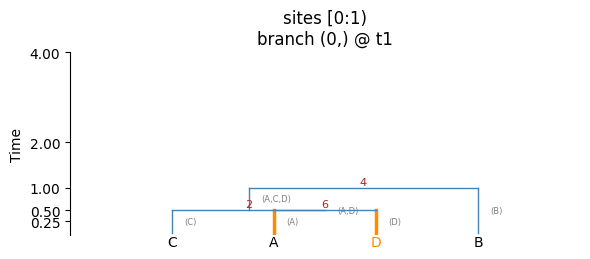


=== episode step 25 | leaf D | site 1 ===
Action probabilities:
  row 00 -> env action 00 | p=0.0828 | [leaf D] site 1 -> branch (A) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.0829 | [leaf D] site 1 -> branch (A) @ t1=0.50 [stay]
  row 02 -> env action 02 | p=0.0830 | [leaf D] site 1 -> branch (A) @ t2=1.00 [stay]
  row 03 -> env action 03 | p=0.0833 | [leaf D] site 1 -> branch (A) @ t3=2.00 [stay]
  row 04 -> env action 04 | p=0.0836 | [leaf D] site 1 -> branch (C) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.0837 | [leaf D] site 1 -> branch (C) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.0839 | [leaf D] site 1 -> branch (C) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.0840 | [leaf D] site 1 -> branch (A,C) @ t4=4.00 [recomb]
  row 08 -> env action 08 | p=0.0830 | [leaf D] site 1 -> branch (B) @ t0=0.25 [recomb]
  row 09 -> env action 09 | p=0.0830 | [leaf D] site 1 -> branch (B) @ t1=0.50 [recomb]
  row 10 -> env action 10 | p=0.0832 | [leaf D] site 1 -> bra

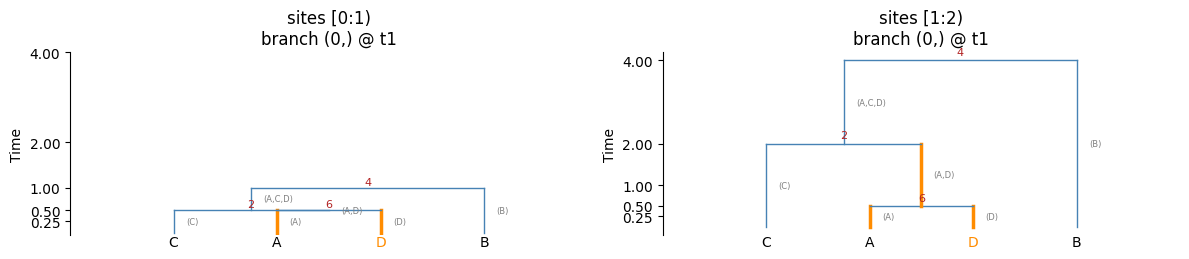


=== episode step 26 | leaf D | site 2 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1658 | [leaf D] site 2 -> branch (A) @ t0=0.25 [stay]
  row 01 -> env action 01 | p=0.1672 | [leaf D] site 2 -> branch (A,B) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1653 | [leaf D] site 2 -> branch (C) @ t0=0.25 [recomb]
  row 03 -> env action 03 | p=0.1664 | [leaf D] site 2 -> branch root @ t2=1.00 [recomb]
  row 04 -> env action 04 | p=0.1670 | [leaf D] site 2 -> branch root @ t3=2.00 [recomb]
  row 05 -> env action 05 | p=0.1682 | [leaf D] site 2 -> branch root @ t4=4.00 [recomb]
Selected: row 3 -> env action 3 | [leaf D] site 2 -> branch root @ t2=1.00 [recomb]
Local log reward: -39.9146 | positive reward factor: 4.6273e-18
Local tree sequence after selected action:


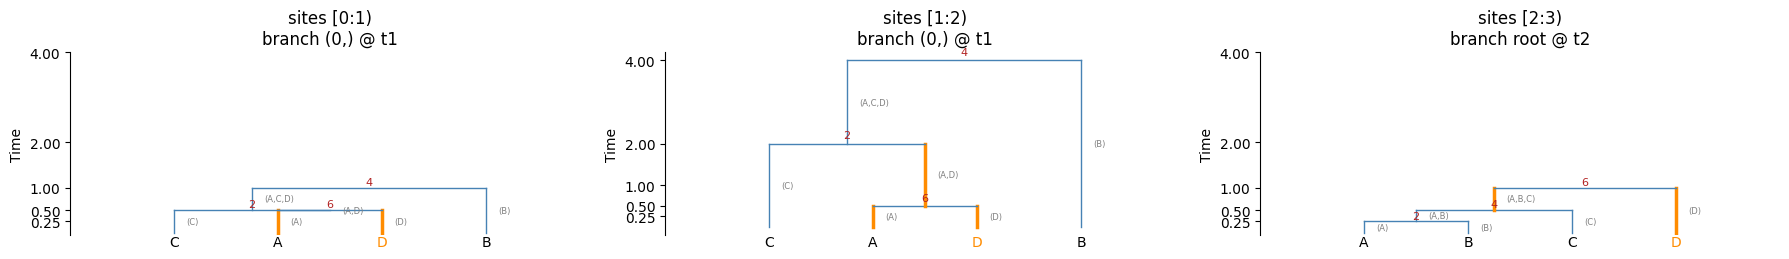


=== episode step 27 | leaf D | site 3 ===
Action probabilities:
  row 00 -> env action 00 | p=0.0998 | [leaf D] site 3 -> branch (A) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.0998 | [leaf D] site 3 -> branch (A) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1000 | [leaf D] site 3 -> branch (A) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.0995 | [leaf D] site 3 -> branch (B) @ t0=0.25 [recomb]
  row 04 -> env action 04 | p=0.0996 | [leaf D] site 3 -> branch (B) @ t1=0.50 [recomb]
  row 05 -> env action 05 | p=0.1012 | [leaf D] site 3 -> branch (A,B) @ t3=2.00 [recomb]
  row 06 -> env action 06 | p=0.0995 | [leaf D] site 3 -> branch (C) @ t0=0.25 [recomb]
  row 07 -> env action 07 | p=0.0996 | [leaf D] site 3 -> branch (C) @ t1=0.50 [recomb]
  row 08 -> env action 08 | p=0.0997 | [leaf D] site 3 -> branch (C) @ t2=1.00 [recomb]
  row 09 -> env action 09 | p=0.1012 | [leaf D] site 3 -> branch root @ t4=4.00 [stay]
Selected: row 6 -> env action 6 | [leaf D] site 3 -> b

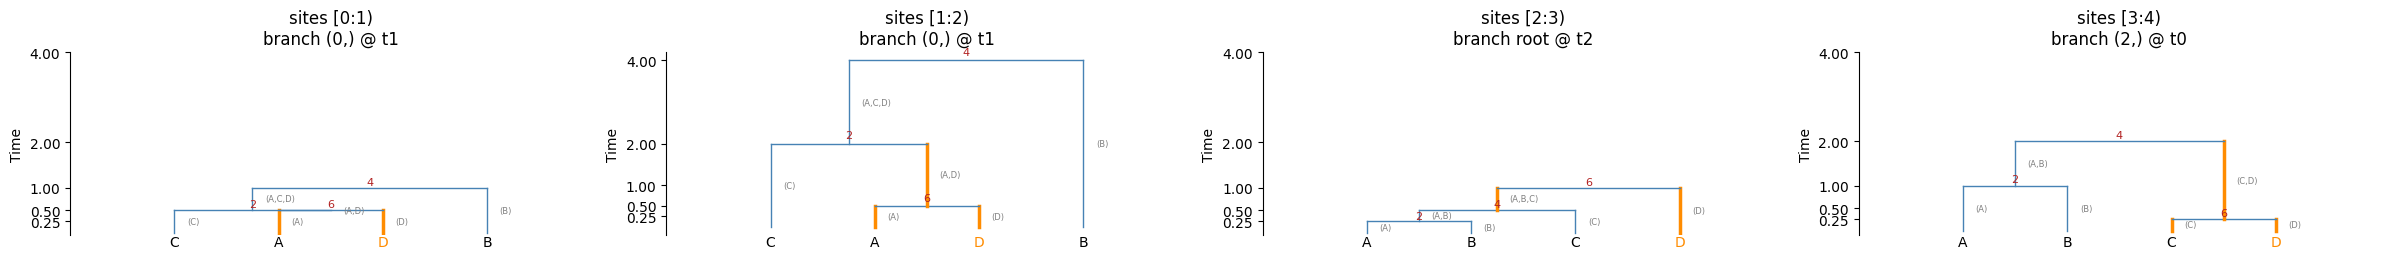


=== episode step 28 | leaf D | site 4 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1005 | [leaf D] site 4 -> branch (A) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1006 | [leaf D] site 4 -> branch (A) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1008 | [leaf D] site 4 -> branch (A) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1012 | [leaf D] site 4 -> branch (A) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.0990 | [leaf D] site 4 -> branch (B) @ t0=0.25 [recomb]
  row 05 -> env action 05 | p=0.0991 | [leaf D] site 4 -> branch (B) @ t1=0.50 [recomb]
  row 06 -> env action 06 | p=0.0993 | [leaf D] site 4 -> branch (B) @ t2=1.00 [recomb]
  row 07 -> env action 07 | p=0.0992 | [leaf D] site 4 -> branch (C) @ t0=0.25 [recomb]
  row 08 -> env action 08 | p=0.0993 | [leaf D] site 4 -> branch (C) @ t1=0.50 [recomb]
  row 09 -> env action 09 | p=0.1010 | [leaf D] site 4 -> branch root @ t4=4.00 [recomb]
Selected: row 7 -> env action 7 | [leaf D] site 4 -> b

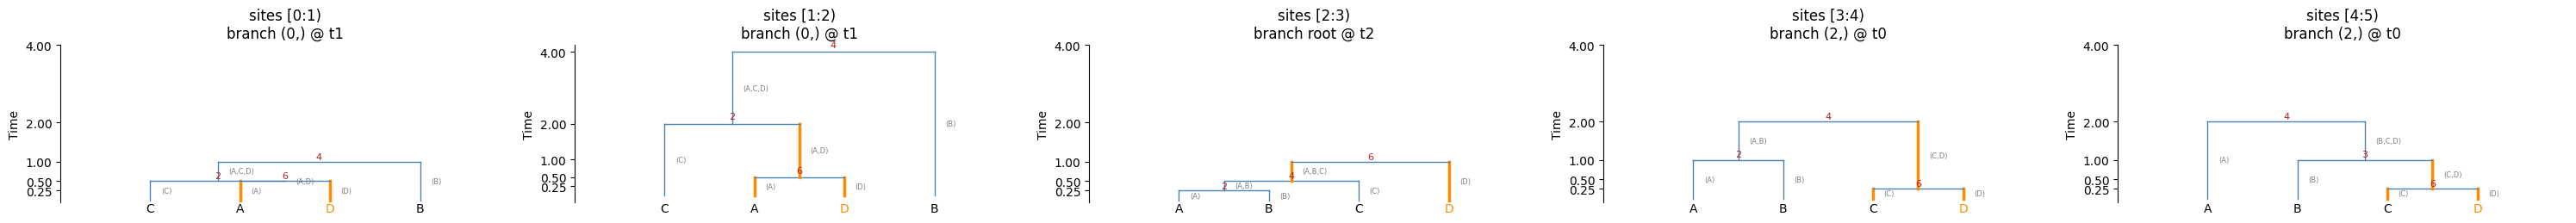


=== episode step 29 | leaf D | site 5 ===
Action probabilities:
  row 00 -> env action 00 | p=0.0709 | [leaf D] site 5 -> branch (B) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.0709 | [leaf D] site 5 -> branch (B) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.0711 | [leaf D] site 5 -> branch (B) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.0713 | [leaf D] site 5 -> branch (B) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.0719 | [leaf D] site 5 -> branch (B) @ t4=4.00 [recomb]
  row 05 -> env action 05 | p=0.0716 | [leaf D] site 5 -> branch (A) @ t0=0.25 [recomb]
  row 06 -> env action 06 | p=0.0716 | [leaf D] site 5 -> branch (A) @ t1=0.50 [recomb]
  row 07 -> env action 07 | p=0.0718 | [leaf D] site 5 -> branch (A) @ t2=1.00 [recomb]
  row 08 -> env action 08 | p=0.0721 | [leaf D] site 5 -> branch (A) @ t3=2.00 [recomb]
  row 09 -> env action 09 | p=0.0726 | [leaf D] site 5 -> branch (A) @ t4=4.00 [recomb]
  row 10 -> env action 10 | p=0.0709 | [leaf D] site 5 

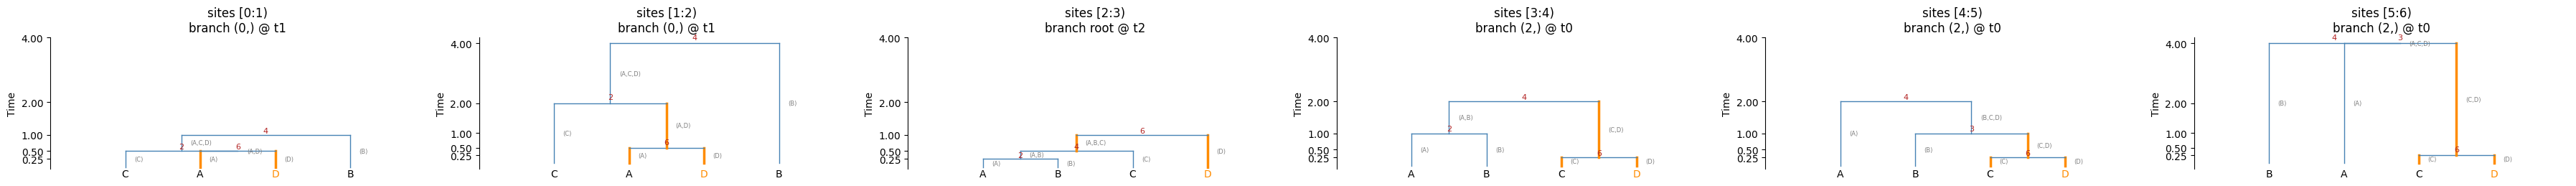


=== episode step 30 | leaf D | site 6 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1106 | [leaf D] site 6 -> branch (A) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1107 | [leaf D] site 6 -> branch (A,C) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1109 | [leaf D] site 6 -> branch (A,C) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1113 | [leaf D] site 6 -> branch (A,C) @ t3=2.00 [recomb]
  row 04 -> env action 04 | p=0.1122 | [leaf D] site 6 -> branch (A,C) @ t4=4.00 [recomb]
  row 05 -> env action 05 | p=0.1108 | [leaf D] site 6 -> branch (B) @ t0=0.25 [recomb]
  row 06 -> env action 06 | p=0.1109 | [leaf D] site 6 -> branch (B) @ t1=0.50 [recomb]
  row 07 -> env action 07 | p=0.1111 | [leaf D] site 6 -> branch (B) @ t2=1.00 [recomb]
  row 08 -> env action 08 | p=0.1115 | [leaf D] site 6 -> branch (B) @ t3=2.00 [recomb]
Selected: row 8 -> env action 8 | [leaf D] site 6 -> branch (B) @ t3=2.00 [recomb]
Local log reward: -45.2119 | positive reward factor:

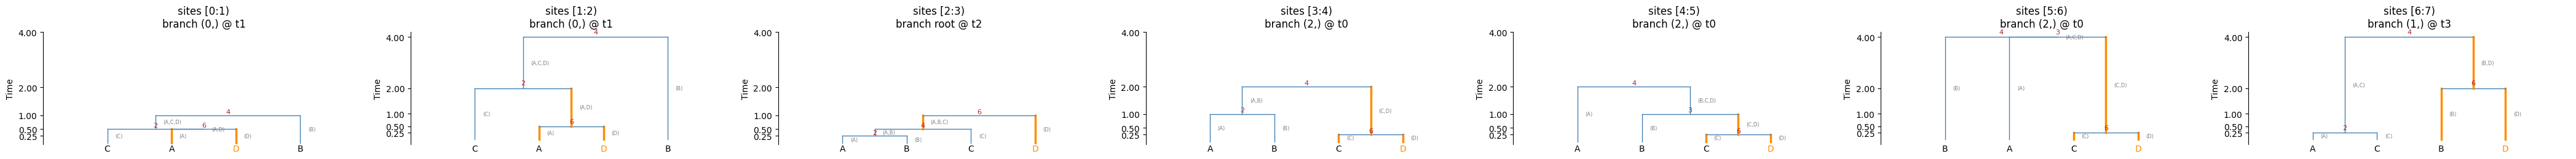


=== episode step 31 | leaf D | site 7 ===
Action probabilities:
  row 00 -> env action 00 | p=0.1422 | [leaf D] site 7 -> branch (A) @ t0=0.25 [recomb]
  row 01 -> env action 01 | p=0.1424 | [leaf D] site 7 -> branch (A,C) @ t1=0.50 [recomb]
  row 02 -> env action 02 | p=0.1426 | [leaf D] site 7 -> branch (A,C) @ t2=1.00 [recomb]
  row 03 -> env action 03 | p=0.1425 | [leaf D] site 7 -> branch (B) @ t0=0.25 [stay]
  row 04 -> env action 04 | p=0.1426 | [leaf D] site 7 -> branch (B) @ t1=0.50 [stay]
  row 05 -> env action 05 | p=0.1432 | [leaf D] site 7 -> branch root @ t3=2.00 [recomb]
  row 06 -> env action 06 | p=0.1444 | [leaf D] site 7 -> branch root @ t4=4.00 [recomb]
Selected: row 6 -> env action 6 | [leaf D] site 7 -> branch root @ t4=4.00 [recomb]
Local log reward: -56.0128 | positive reward factor: 4.7199e-25
Local tree sequence after selected action:


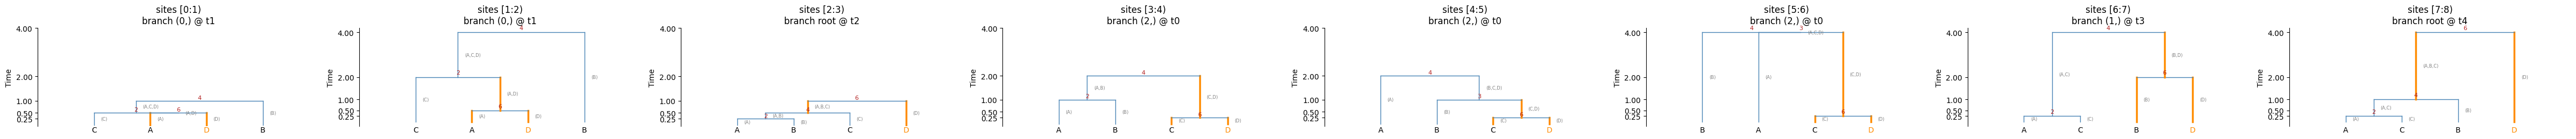


=== episode summary ===
steps: 32
total additive log reward: -1300.9611
loss: -46064.0703
leaves threaded: (0, 1, 2, 3)
selected actions:
  step 00 | leaf A | site 0 | row 05 -> env action 05 | p=0.1249 | local_log_reward=-32.5865 | [leaf A] site 0 -> branch (C,D) @ t1=0.50 [start]
  step 01 | leaf A | site 1 | row 00 -> env action 00 | p=0.1251 | local_log_reward=-30.7674 | [leaf A] site 1 -> branch (B) @ t0=0.25 [recomb]
  step 02 | leaf A | site 2 | row 04 -> env action 04 | p=0.1232 | local_log_reward=-44.8811 | [leaf A] site 2 -> branch (C) @ t0=0.25 [recomb]
  step 03 | leaf A | site 3 | row 01 -> env action 01 | p=0.1253 | local_log_reward=-33.4435 | [leaf A] site 3 -> branch (B) @ t1=0.50 [recomb]
  step 04 | leaf A | site 4 | row 00 -> env action 00 | p=0.1242 | local_log_reward=-30.7674 | [leaf A] site 4 -> branch (C) @ t0=0.25 [recomb]
  step 05 | leaf A | site 5 | row 01 -> env action 01 | p=0.1243 | local_log_reward=-33.4435 | [leaf A] site 5 -> branch (C) @ t1=0.50 [stay

In [14]:
## One episode REINFORCE loop with additive local log rewards
## Shows action probabilities, per-action local rewards, and the local tree sequence.

if "optimizer" not in globals():
    optimizer = torch.optim.Adam(policy_model.parameters(), lr=1e-3)

policy_model.train()
st = env.reset()
saved_log_probs = []
episode_actions = []
step_log_rewards = []
done = False
step_idx = 0


def _choice_key(choice):
    return choice.branch_child, choice.branch_signature


while not done:
    assert env._inner_env is not None and st.inner_state is not None
    inner_env = env._inner_env
    inner_state = st.inner_state
    site_idx = inner_state.site_index

    valid_acts = env.valid_actions(st)
    if not valid_acts:
        raise RuntimeError(f"No valid actions at episode step {step_idx}")

    # Keep action_choices aligned with valid_acts: row j in action_probs maps to valid_acts[j].
    action_choices = [inner_env.site_choices[site_idx][action_idx] for action_idx in valid_acts]
    site_tree = inner_env._site_tree_for_encoding(inner_state)
    action_logits, action_probs, edge_features, node_embeddings, leaf_feature = policy_model(
        site_tree,
        st.current_focal_leaf,
        action_choices,
        time_grid=env_cfg.time_grid,
    )

    focal_name = LEAF_NAMES[st.current_focal_leaf]
    print(f"\n=== episode step {step_idx} | leaf {focal_name} | site {site_idx} ===")
    print("Action probabilities:")
    probs_cpu = action_probs.detach().cpu()
    for row_idx, (action_idx, prob) in enumerate(zip(valid_acts, probs_cpu)):
        desc = env.describe_action(st, action_idx, leaf_names=LEAF_NAMES)
        print(f"  row {row_idx:02d} -> env action {action_idx:02d} | p={prob.item():.4f} | {desc}")

    dist = torch.distributions.Categorical(probs=action_probs)
    selected_row = dist.sample()
    selected_row_idx = int(selected_row.item())
    selected_action = valid_acts[selected_row_idx]
    selected_choice = action_choices[selected_row_idx]
    selected_desc = env.describe_action(st, selected_action, leaf_names=LEAF_NAMES)
    saved_log_probs.append(dist.log_prob(selected_row))
    print(f"Selected: row {selected_row_idx} -> env action {selected_action} | {selected_desc}")

    # Build a preview state for visualization before env.step potentially advances to the next leaf.
    recomb_count = inner_state.recomb_count
    if inner_state.choices and _choice_key(selected_choice) != _choice_key(inner_state.choices[-1]):
        recomb_count += 1
    preview_inner_state = type(inner_state)(
        site_index=site_idx + 1,
        choices=inner_state.choices + (selected_choice,),
        recomb_count=recomb_count,
    )

    st, local_log_reward, done = env.step(st, selected_action)
    step_log_rewards.append(float(local_log_reward))
    print(
        f"Local log reward: {local_log_reward:.4f} | "
        f"positive reward factor: {float(np.exp(local_log_reward)):.4e}"
    )

    episode_actions.append(
        {
            "step": step_idx,
            "leaf": focal_name,
            "site": site_idx,
            "row": selected_row_idx,
            "env_action": int(selected_action),
            "prob": float(probs_cpu[selected_row_idx].item()),
            "local_log_reward": float(local_log_reward),
            "description": selected_desc,
        }
    )

    local_trees = inner_env.snapshot_state(preview_inner_state)
    if local_trees:
        print("Local tree sequence after selected action:")
        draw_local_tree_sequence(
            local_trees,
            leaf_names=LEAF_NAMES,
            time_grid=TIME_GRID,
            use_time_as_y=True,
        )
        plt.show()
    else:
        print("No local tree sequence yet.")

    step_idx += 1

log_probs_t = torch.stack(saved_log_probs)
step_log_rewards_t = torch.tensor(step_log_rewards, dtype=log_probs_t.dtype, device=log_probs_t.device)
reward_to_go = torch.flip(
    torch.cumsum(torch.flip(step_log_rewards_t, dims=[0]), dim=0),
    dims=[0],
)
total_log_reward = step_log_rewards_t.sum()
loss = -(reward_to_go.detach() * log_probs_t).sum()

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("\n=== episode summary ===")
print(f"steps: {step_idx}")
print(f"total additive log reward: {total_log_reward.item():.4f}")
print(f"loss: {loss.item():.4f}")
print(f"leaves threaded: {st.leaves_threaded}")
print("selected actions:")
for action in episode_actions:
    print(
        f"  step {action['step']:02d} | leaf {action['leaf']} | site {action['site']} | "
        f"row {action['row']:02d} -> env action {action['env_action']:02d} | "
        f"p={action['prob']:.4f} | local_log_reward={action['local_log_reward']:.4f} | "
        f"{action['description']}"
    )

## Misc..

In [ ]:
# --- Valid-action edge features (focal leaf x attachment target x time) ---


def extract_valid_action_choices(
    env, st, valid_action_indices: list[int]
):
    """Map flat action indices to :class:`ThreadChoice` and stacked tensors."""
    assert env._inner_env is not None and st.inner_state is not None
    site_choices = env._inner_env.site_choices[st.inner_state.site_index]
    choices = [site_choices[i] for i in valid_action_indices]
    return choices


def valid_action_choices_to_tensors(choices, device, dtype=torch.float32):
    branch_child = torch.tensor(
        [c.branch_child for c in choices], dtype=torch.long, device=device
    )
    time_idx = torch.tensor(
        [c.time_idx for c in choices], dtype=torch.long, device=device
    )
    time_value = torch.tensor(
        [float(c.time_value) for c in choices], dtype=dtype, device=device
    )
    is_root = torch.tensor(
        [1.0 if c.is_root_branch else 0.0 for c in choices],
        dtype=dtype,
        device=device,
    )
    return branch_child, time_idx, time_value, is_root


def normalize_time_values(
    time_value: torch.Tensor, time_grid: tuple
) -> torch.Tensor:
    """[0,1] normalized time w.r.t. grid min/max (matches plan: scalar time)."""
    tg = torch.tensor(time_grid, dtype=time_value.dtype, device=time_value.device)
    t_min, t_max = tg[0], tg[-1]
    return (time_value - t_min) / (t_max - t_min + 1e-8)

In [ ]:
import torch.nn as nn


def build_valid_action_edge_features(
    node_embeddings: torch.Tensor,
    leaf_feature: torch.Tensor,
    policy_model: Policy,
    branch_child: torch.Tensor,
    time_value: torch.Tensor,
    is_root: torch.Tensor,
    time_grid: tuple,
) -> torch.Tensor:
    """
    h_e = f({h_focal, h_v}) with permutation-invariant MLP input:
    concat( h_f, h_v, |h_f-h_v|, h_f * h_v, t_norm, is_root ).
    h_f = focal_proj(one_hot_leaf), h_v = GNN node embedding of attachment branch child.
    """
    device, dtype = node_embeddings.device, node_embeddings.dtype
    leaf_feature = leaf_feature.to(device=device, dtype=dtype)
    h_f = policy_model.focal_proj(leaf_feature.unsqueeze(0)).squeeze(0)  # (D,)
    h_v = node_embeddings[branch_child]  # (A, D)
    h_f_b = h_f.unsqueeze(0).expand_as(h_v)
    t_norm = normalize_time_values(time_value, time_grid).unsqueeze(-1).to(dtype=dtype)
    h_e = torch.cat(
        [h_f_b, h_v, (h_f_b - h_v).abs(), h_f_b * h_v, t_norm, is_root.unsqueeze(-1)],
        dim=-1,
    )
    return h_e


def assert_valid_action_edge_alignment(
    env, st, valid_action_indices, choices, branch_child, h_e, site_tree_num_nodes: int
):
    assert h_e.shape[0] == len(
        valid_action_indices
    ), f"edge rows {h_e.shape[0]} != len(valid) {len(valid_action_indices)}"
    inner = env._inner_env
    sc = inner.site_choices[st.inner_state.site_index]
    for i, aidx in enumerate(valid_action_indices):
        assert sc[aidx] == choices[i]
    assert (branch_child >= 0).all() and (branch_child < site_tree_num_nodes).all()

In [ ]:
# --- One-shot pipeline (re-run to sample a fresh start state) ---
st = env.reset()
valid_acts = env.valid_actions(st)
assert len(valid_acts) > 0, "need non-terminal state with valid actions"

site_tree = env._inner_env._site_tree_for_encoding(st.inner_state)
choices = extract_valid_action_choices(env, st, valid_acts)
action_logits, action_probs, edge_features, node_embeddings, leaf_feature = policy_model(
    site_tree,
    st.current_focal_leaf,
    choices,
    time_grid=env_cfg.time_grid,
)

branch_child, time_idx, time_value, is_root = valid_action_choices_to_tensors(
    choices, device=node_embeddings.device, dtype=node_embeddings.dtype
)
assert_valid_action_edge_alignment(
    env,
    st,
    valid_acts,
    choices,
    branch_child,
    edge_features,
    site_tree_num_nodes=site_tree.num_nodes,
)
print("edge feature matrix:", edge_features.shape, "(rows align with valid_acts in order)")
print("probs sum:", action_probs.sum().item())

K = min(5, action_probs.shape[0])
print(f"\nTop {K} actions (policy action head):")
for rank, j in enumerate(torch.topk(action_probs, K).indices.tolist()):
    aidx = valid_acts[j]
    print(
        f"  {rank+1}. p={action_probs[j].item():.4f}  aidx={aidx}  {env.describe_action(st, aidx, leaf_names=LEAF_NAMES)}"
    )
    print(
        f"        branch_child={choices[j].branch_child}  time_idx={choices[j].time_idx}  t={choices[j].time_value}"
    )

In [12]:
st = env.reset()
valid_acts = env.valid_actions(st)
print("number of valid actions for the given input ARG .. local tree is", len(valid_acts))

number of valid actions for the given input ARG .. local tree is 8


[leaf A] site 0 -> branch (B) @ t0=0.25 [start]
ThreadChoice(site=0, branch_child=0, branch_signature=(1,), time_idx=0, time_value=0.25, is_root_branch=False)


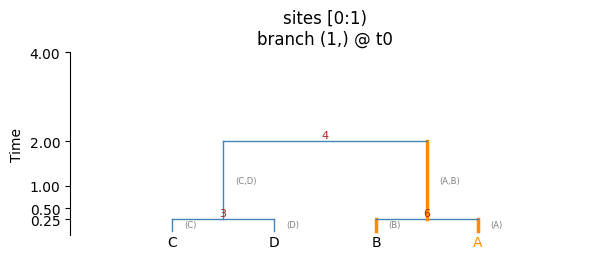

interactive(children=(IntSlider(value=0, description='Action Index', max=7), Output()), _dom_classes=('widget-…

<function __main__.plot_action(i)>

In [14]:
import ipywidgets as widgets
from IPython.display import display

## Possible Actions space for single Site

def plot_action(i):
    st = env.reset()
    k = env.describe_action(st, valid_acts[i], leaf_names=LEAF_NAMES)
    print(k)
    
    choice = env._inner_env.site_choices[st.inner_state.site_index][valid_acts[i]]
    print(choice)
    # print(choice.branch_signature, choice.time_value)
    st, reward, done = env.step(st, valid_acts[i])
    local_trees = env._inner_env.snapshot_state(st.inner_state)
    draw_local_tree_sequence(local_trees, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)

widgets.interact(plot_action, i=widgets.IntSlider(min=0, max=len(valid_acts)-1, step=1, value=0, description='Action Index'))

In [ ]:
## Policy 
# policy = ARGForwardPolicy(initializing parameters)

reward = []
## I feel like there's no need for encoding step. 
## Just send the state directly to forward function of the policy and 
## it should output all the probs to attach to. 
action_probs, masked_logits = policy(st)
action_idx = max(action_probs) ## choose the action
next_st, action_reward, done = env.step(st, action)

if done:
    reward.append(action_reward)